# Myeloid Annotation Cross-Comparison
**Date:** 2026-03-29  
**Purpose:** Cross-tabulate L2/L3 annotation columns to inspect mutual relationships  
**Input:** `adata_myeloid_refined_FINAL.h5ad`

### Target columns
| Column | Source | N unique |
|---|---|---|
| `cell_type_L2` | scANVI pipeline | 9 |
| `cell_type_L3` | subcluster IDs | 25 |
| `cell_type_L3_refined` | manual refinement | 15 |
| `ann_level_2` | reference atlas | 39 |
| `ann_level_3` | reference atlas | 32 |
| `scanvi_predictions` | scANVI (ref model) | 15 |
| `majority_voting` | CellTypist | 10 |

In [1]:
# ===== 0. Imports & Config =====
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

INPUT_PATH = Path("/home/h2048/data/py/0209/myeloid_validation_optimized/adata_myeloid_refined_FINAL.h5ad")

# Columns to compare (all L2/L3 annotation sources)
TARGET_COLS = [
    'cell_type_L2',
    'cell_type_L3',
    'cell_type_L3_refined',
    'ann_level_2',
    'ann_level_3',
    'scanvi_predictions',
    'majority_voting',
]

sc.settings.verbosity = 1
print(f"Input: {INPUT_PATH}")

Input: /home/h2048/data/py/0209/myeloid_validation_optimized/adata_myeloid_refined_FINAL.h5ad


In [2]:
# ===== 1. Load Data =====
adata = sc.read_h5ad(INPUT_PATH)
print(f"Shape: {adata.shape}")

# Check which target columns actually exist
available = [c for c in TARGET_COLS if c in adata.obs.columns]
missing   = [c for c in TARGET_COLS if c not in adata.obs.columns]
print(f"\nAvailable ({len(available)}): {available}")
print(f"Missing   ({len(missing)}): {missing}")

Shape: (54731, 35112)

Available (7): ['cell_type_L2', 'cell_type_L3', 'cell_type_L3_refined', 'ann_level_2', 'ann_level_3', 'scanvi_predictions', 'majority_voting']
Missing   (0): []


In [3]:
# ===== 2. Value Counts for Each Column =====
for col in available:
    vc = adata.obs[col].value_counts(dropna=False)
    print(f"\n{'='*60}")
    print(f"  {col}  (n_unique={adata.obs[col].nunique(dropna=False)})")
    print('='*60)
    print(vc.to_string())


  cell_type_L2  (n_unique=9)
cell_type_L2
Alveolar macrophages       24144
Macrophages                13892
Classical monocytes         8908
Mast cells                  3726
Non-classical monocytes     2029
DC2                         1032
Intestinal macrophages       386
pDC                          335
DC                           279

  cell_type_L3  (n_unique=25)
cell_type_L3
Alveolar macrophages_c0       9341
Alveolar macrophages_c1       5591
Alveolar macrophages_c2       5501
Macrophages_c0                5092
Macrophages_c1                4918
Classical monocytes_c0        4054
Macrophages_c2                3882
Alveolar macrophages_c3       3711
Classical monocytes_c1        3675
Mast cells_c0                 1972
Mast cells_c1                 1754
Classical monocytes_c2        1179
Non-classical monocytes_c0    1112
Non-classical monocytes_c1     917
DC2_c0                         587
DC2_c1                         445
DC_c0                          244
pDC_c0               

In [4]:
# ===== 3. Helper: Normalized Crosstab Heatmap =====
def plot_crosstab(df, col_row, col_col, title=None, figsize=None,
                  min_cells=20, normalize='index', fmt='.0f',
                  show_counts=True, max_cols=30, max_rows=30):
    """
    Plot a crosstab heatmap.
    normalize: 'index'=row-wise %, 'columns'=col-wise %, None=counts
    """
    ct = pd.crosstab(df[col_row], df[col_col])

    # Drop very small groups
    ct = ct.loc[ct.sum(axis=1) >= min_cells, :]
    ct = ct.loc[:, ct.sum(axis=0) >= min_cells]

    # Trim if too wide/tall
    ct = ct.iloc[:max_rows, :max_cols]

    if ct.empty:
        print(f"  [SKIP] {col_row} x {col_col}: empty after filtering")
        return

    if normalize == 'index':
        pct = ct.div(ct.sum(axis=1), axis=0) * 100
        cbar_label = 'Row %'
    elif normalize == 'columns':
        pct = ct.div(ct.sum(axis=0), axis=1) * 100
        cbar_label = 'Col %'
    else:
        pct = ct.copy()
        cbar_label = 'Cell count'

    nrow, ncol = pct.shape
    if figsize is None:
        figsize = (max(8, ncol * 0.55 + 2), max(4, nrow * 0.45 + 1.5))

    fig, ax = plt.subplots(figsize=figsize)

    annot_data = None
    if show_counts:
        # Annotate with counts, color by %
        annot_data = ct.values.astype(int)
        annot_fmt = 'd'
    else:
        annot_data = True
        annot_fmt = '.0f'

    sns.heatmap(
        pct,
        annot=annot_data,
        fmt=annot_fmt if show_counts else '.0f',
        cmap='Blues',
        linewidths=0.3,
        linecolor='#dddddd',
        ax=ax,
        cbar_kws={'label': cbar_label},
        vmin=0,
        vmax=100 if normalize else None,
    )
    if title is None:
        title = f"{col_row}  x  {col_col}  (color={cbar_label}, annot=counts)"
    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel(col_col, fontsize=9)
    ax.set_ylabel(col_row, fontsize=9)
    ax.tick_params(axis='x', labelrotation=45, labelsize=7)
    ax.tick_params(axis='y', labelrotation=0,  labelsize=7)
    plt.tight_layout()
    plt.show()

print("Helper function defined.")

Helper function defined.


---
## Section A: Primary hierarchy — `cell_type_L2` x `cell_type_L3`

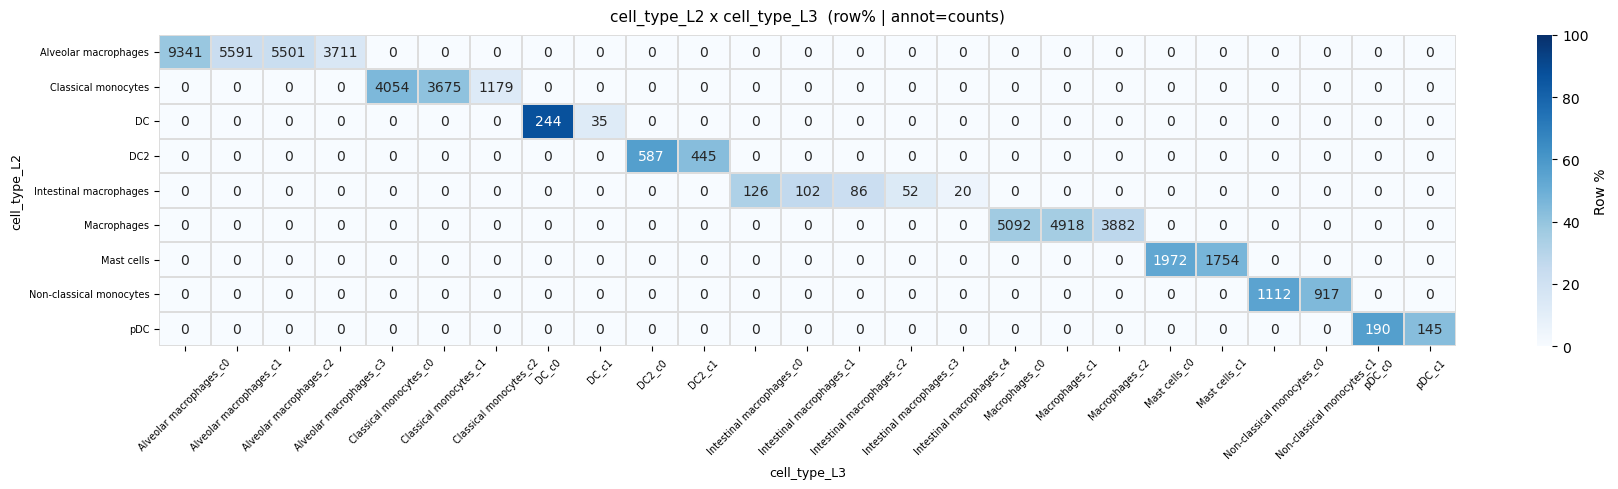

In [5]:
# ===== 4A. L2 x L3 (raw subcluster IDs) =====
# Expect: each L3 belongs to exactly one L2 (hierarchical)
if 'cell_type_L2' in available and 'cell_type_L3' in available:
    plot_crosstab(
        adata.obs, 'cell_type_L2', 'cell_type_L3',
        title='cell_type_L2 x cell_type_L3  (row% | annot=counts)',
        normalize='index', show_counts=True, figsize=(18, 5)
    )

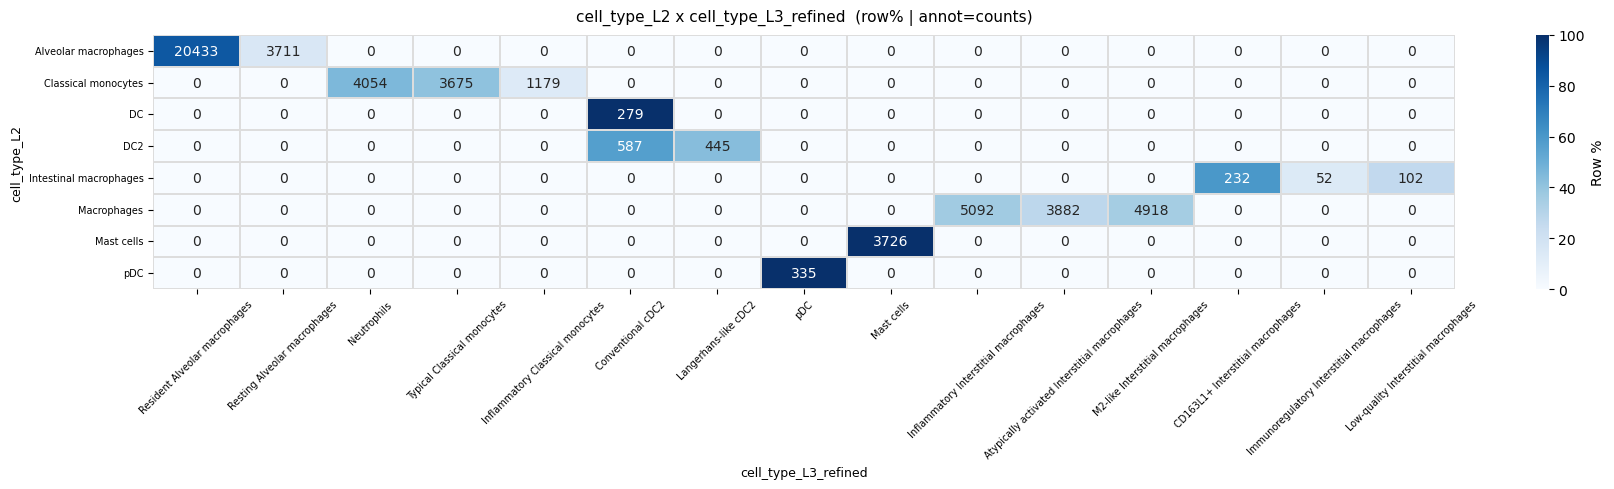

In [6]:
# ===== 4B. L2 x L3_refined =====
# Expect: refined labels clarify substructure within each L2
if 'cell_type_L2' in available and 'cell_type_L3_refined' in available:
    plot_crosstab(
        adata.obs, 'cell_type_L2', 'cell_type_L3_refined',
        title='cell_type_L2 x cell_type_L3_refined  (row% | annot=counts)',
        normalize='index', show_counts=True, figsize=(18, 5)
    )

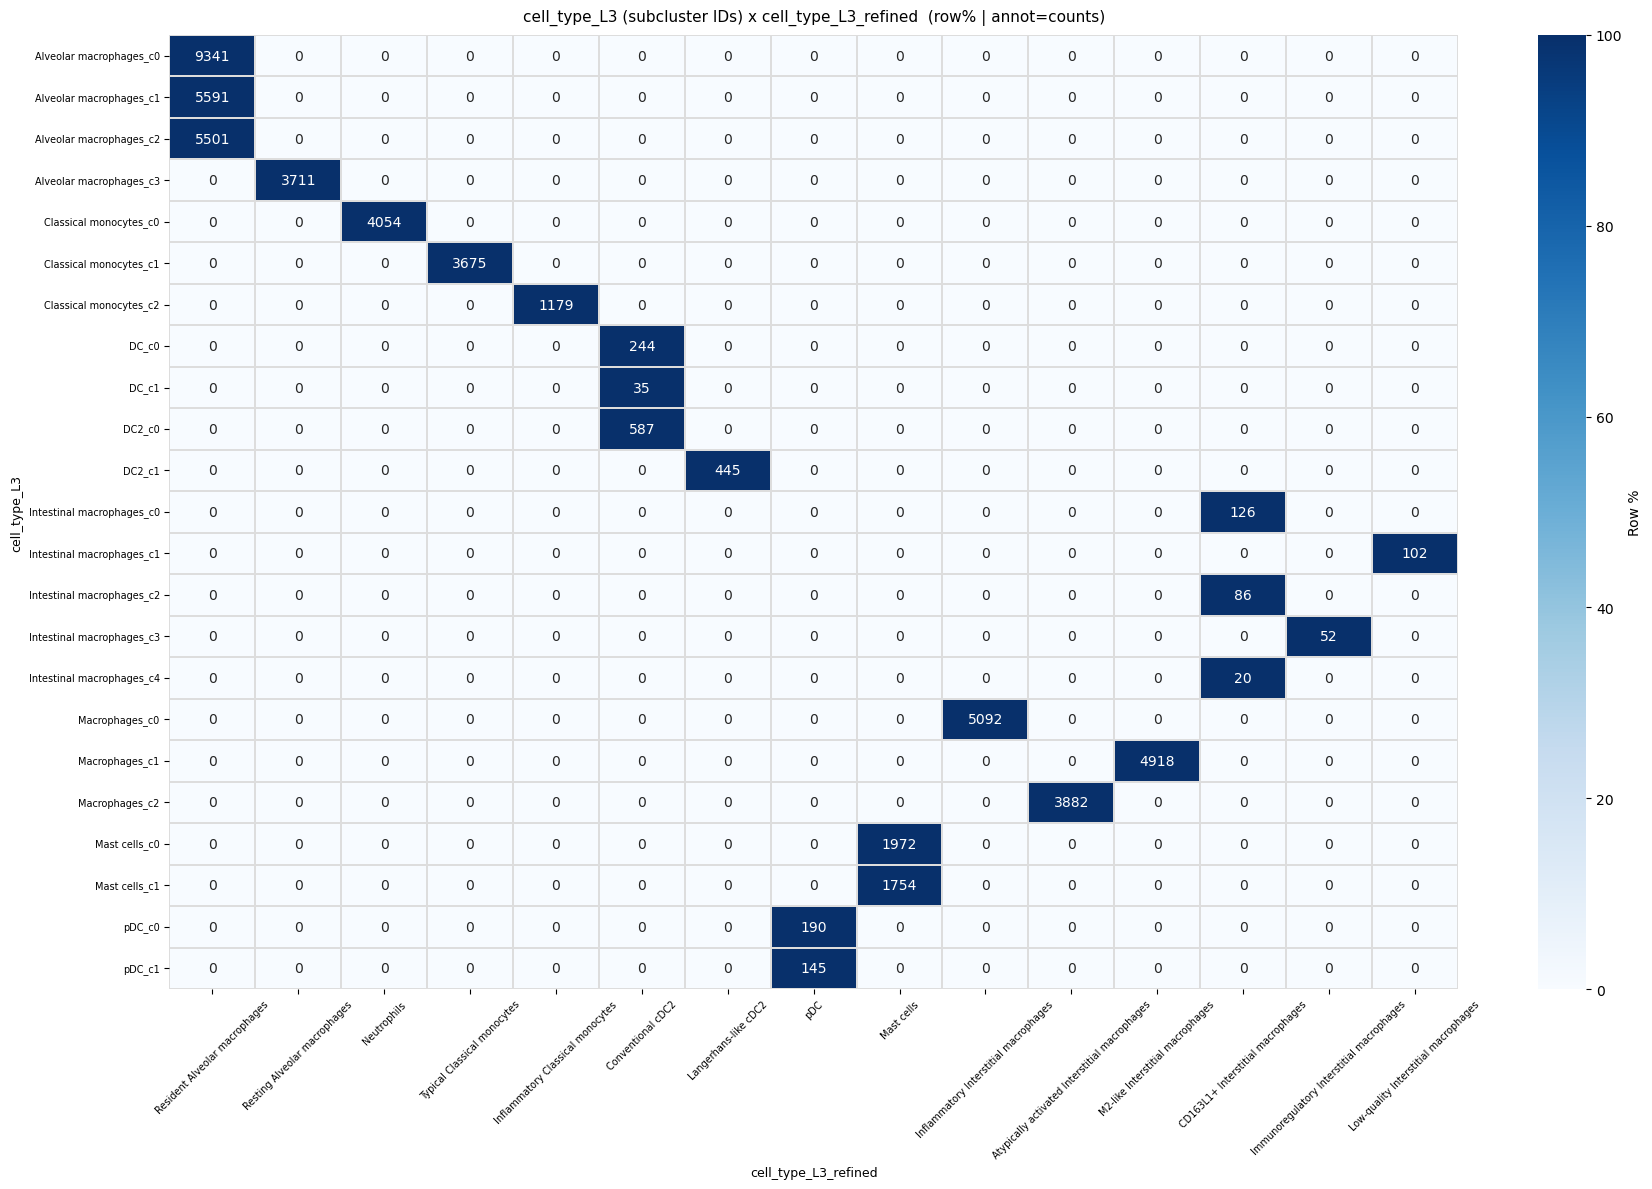

In [7]:
# ===== 4C. L3 x L3_refined =====
# Key check: how do numeric subcluster IDs map to biological refined names?
if 'cell_type_L3' in available and 'cell_type_L3_refined' in available:
    plot_crosstab(
        adata.obs, 'cell_type_L3', 'cell_type_L3_refined',
        title='cell_type_L3 (subcluster IDs) x cell_type_L3_refined  (row% | annot=counts)',
        normalize='index', show_counts=True, figsize=(18, 12)
    )

---
## Section B: Our labels vs reference atlas — `ann_level_2` / `ann_level_3`

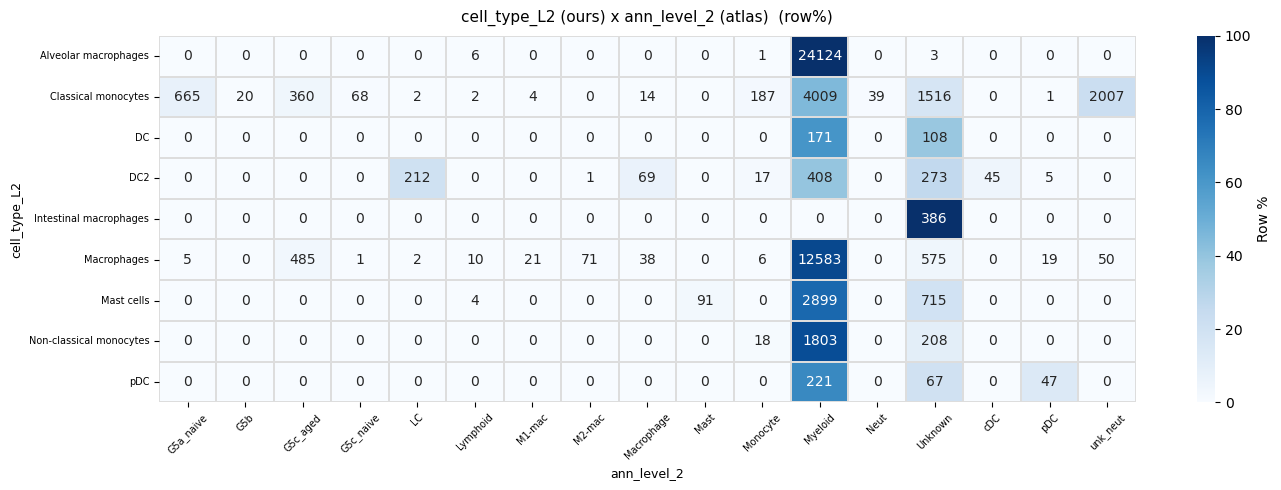

In [8]:
# ===== 5A. cell_type_L2 x ann_level_2 =====
if 'cell_type_L2' in available and 'ann_level_2' in available:
    plot_crosstab(
        adata.obs, 'cell_type_L2', 'ann_level_2',
        title='cell_type_L2 (ours) x ann_level_2 (atlas)  (row%)',
        normalize='index', show_counts=True, figsize=(14, 5)
    )

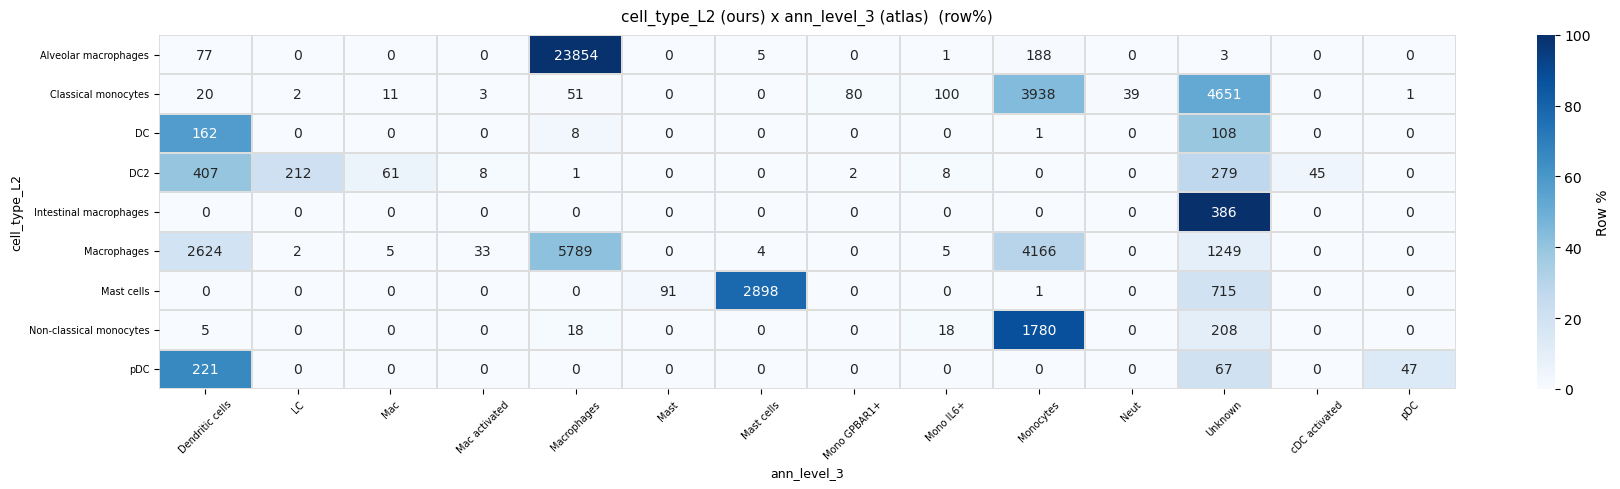

In [9]:
# ===== 5B. cell_type_L2 x ann_level_3 =====
if 'cell_type_L2' in available and 'ann_level_3' in available:
    plot_crosstab(
        adata.obs, 'cell_type_L2', 'ann_level_3',
        title='cell_type_L2 (ours) x ann_level_3 (atlas)  (row%)',
        normalize='index', show_counts=True, figsize=(18, 5)
    )

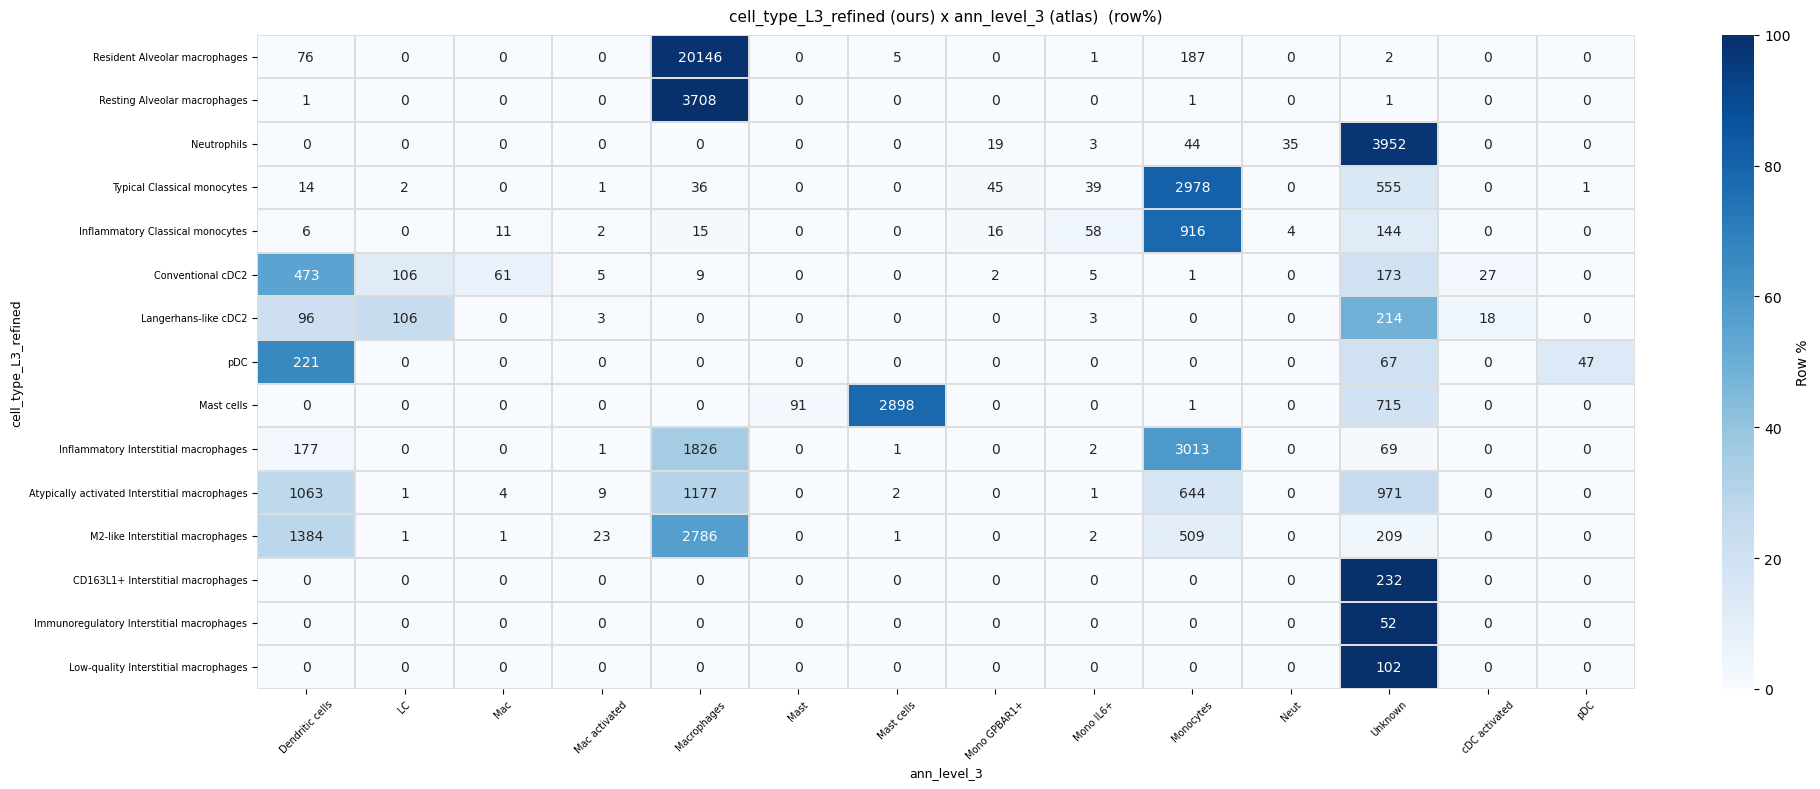

In [10]:
# ===== 5C. cell_type_L3_refined x ann_level_3 =====
# Deepest cross: refined subtype vs atlas finest level
if 'cell_type_L3_refined' in available and 'ann_level_3' in available:
    plot_crosstab(
        adata.obs, 'cell_type_L3_refined', 'ann_level_3',
        title='cell_type_L3_refined (ours) x ann_level_3 (atlas)  (row%)',
        normalize='index', show_counts=True, figsize=(20, 8)
    )

---
## Section C: CellTypist / scANVI predictions vs our labels

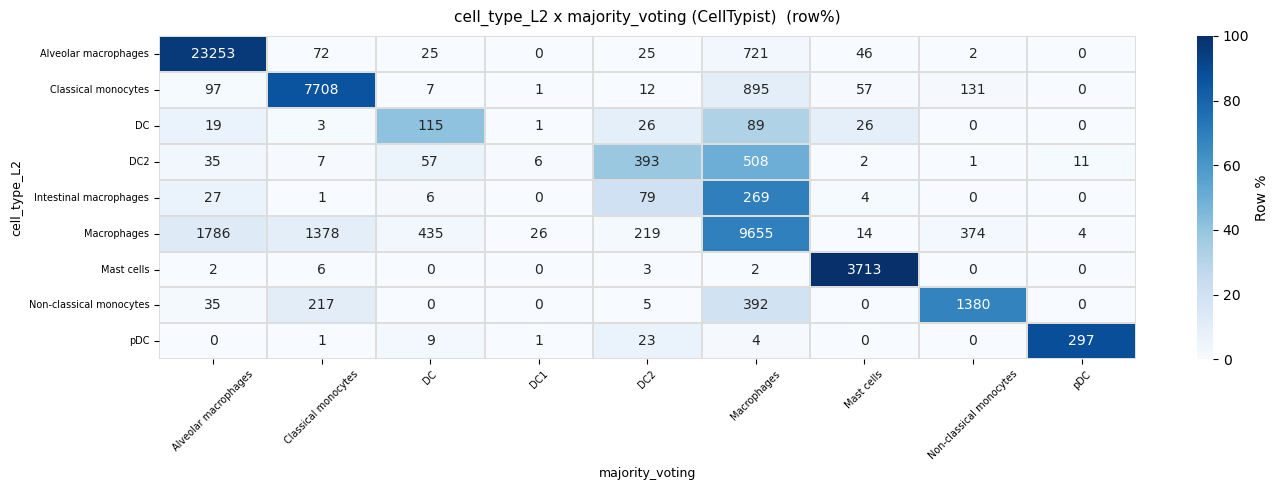

In [11]:
# ===== 6A. cell_type_L2 x majority_voting (CellTypist) =====
if 'cell_type_L2' in available and 'majority_voting' in available:
    plot_crosstab(
        adata.obs, 'cell_type_L2', 'majority_voting',
        title='cell_type_L2 x majority_voting (CellTypist)  (row%)',
        normalize='index', show_counts=True, figsize=(14, 5)
    )

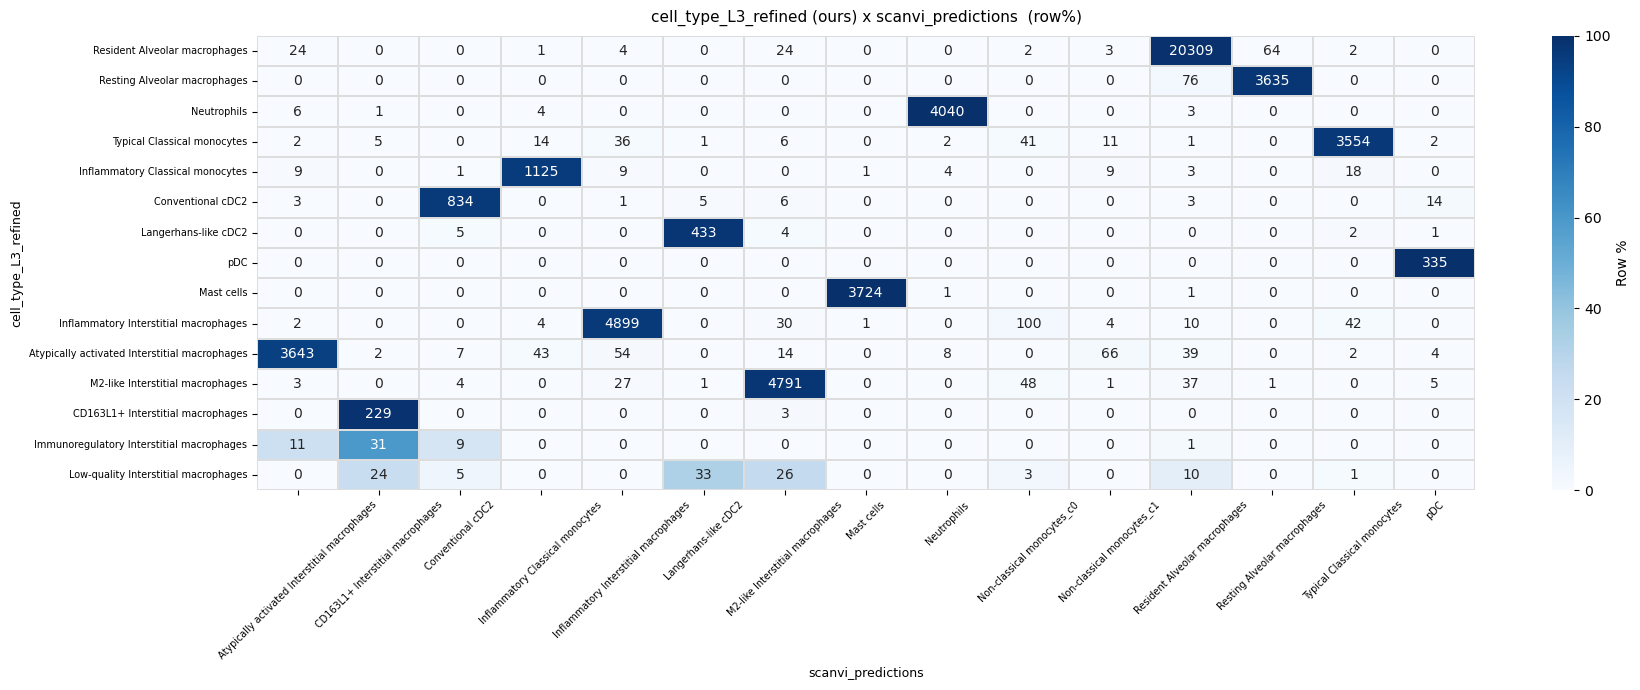

In [12]:
# ===== 6B. cell_type_L3_refined x scanvi_predictions =====
# Most informative: do our refined names match scANVI predictions?
if 'cell_type_L3_refined' in available and 'scanvi_predictions' in available:
    plot_crosstab(
        adata.obs, 'cell_type_L3_refined', 'scanvi_predictions',
        title='cell_type_L3_refined (ours) x scanvi_predictions  (row%)',
        normalize='index', show_counts=True, figsize=(18, 7)
    )

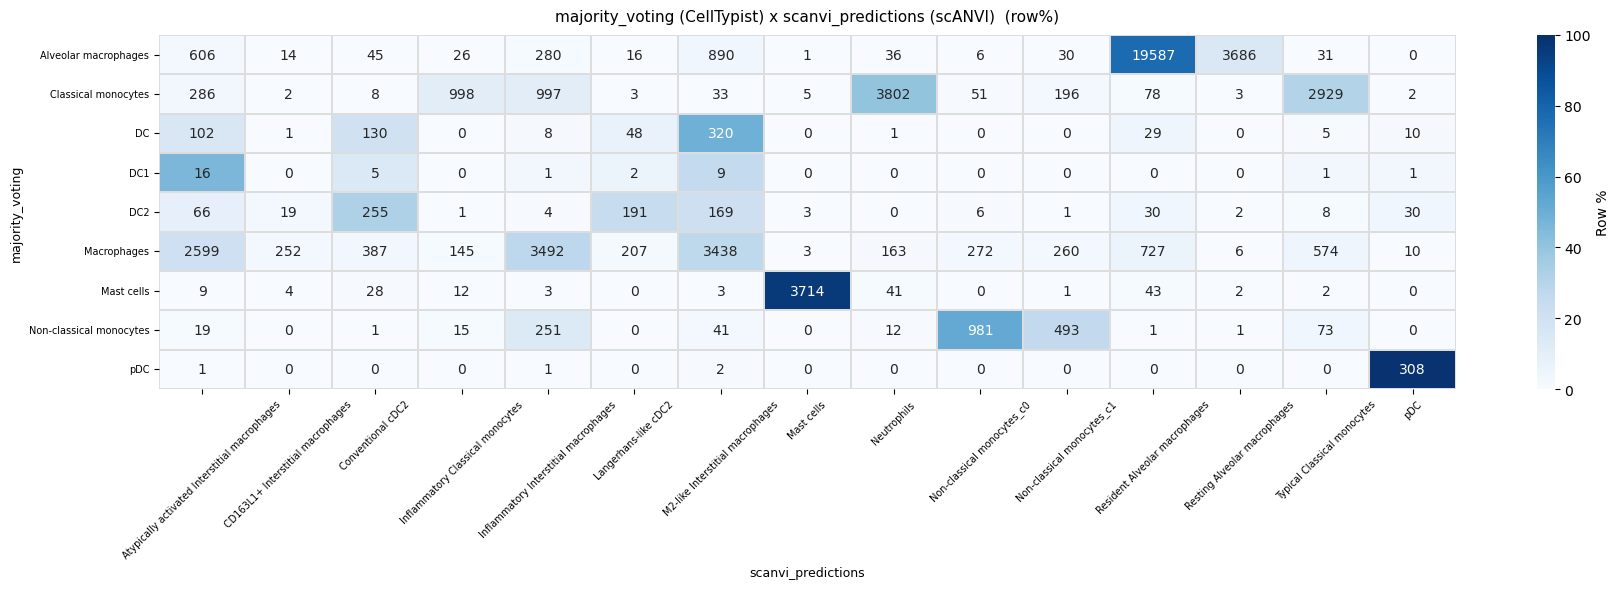

In [13]:
# ===== 6C. majority_voting x scanvi_predictions =====
# CellTypist vs scANVI: two automatic methods compared
if 'majority_voting' in available and 'scanvi_predictions' in available:
    plot_crosstab(
        adata.obs, 'majority_voting', 'scanvi_predictions',
        title='majority_voting (CellTypist) x scanvi_predictions (scANVI)  (row%)',
        normalize='index', show_counts=True, figsize=(18, 6)
    )

---
## Section D: Summary table — L3_refined breakdown within each L2

In [14]:
# ===== 7. Clean summary: L2 -> L3_refined composition =====
if 'cell_type_L2' in available and 'cell_type_L3_refined' in available:
    ct = pd.crosstab(
        adata.obs['cell_type_L2'],
        adata.obs['cell_type_L3_refined'],
        margins=True
    )
    pct = ct.div(ct['All'], axis=0).drop(columns='All').drop(index='All') * 100
    pct = pct.round(1)

    # Add total count column
    pct.insert(0, 'Total_cells', ct.drop(columns='All').drop(index='All').sum(axis=1))

    # Drop zero columns
    nonzero_cols = ['Total_cells'] + [c for c in pct.columns[1:] if pct[c].sum() > 0]
    pct = pct[nonzero_cols]

    print("=== L2 -> L3_refined composition (%) ===")
    print(pct.to_string())
    pct.to_csv("/home/h2048/data/py/0329/myeloid_L2_L3refined_composition.csv")
    print("\nSaved to /home/h2048/data/py/0329/myeloid_L2_L3refined_composition.csv")

=== L2 -> L3_refined composition (%) ===
cell_type_L3_refined    Total_cells  Resident Alveolar macrophages  Resting Alveolar macrophages  Neutrophils  Typical Classical monocytes  Inflammatory Classical monocytes  Conventional cDC2  Langerhans-like cDC2    pDC  Mast cells  Inflammatory Interstitial macrophages  Atypically activated Interstitial macrophages  M2-like Interstitial macrophages  CD163L1+ Interstitial macrophages  Immunoregulatory Interstitial macrophages  Low-quality Interstitial macrophages
cell_type_L2                                                                                                                                                                                                                                                                                                                                                                                                                                                                        
Alveolar macrophages 

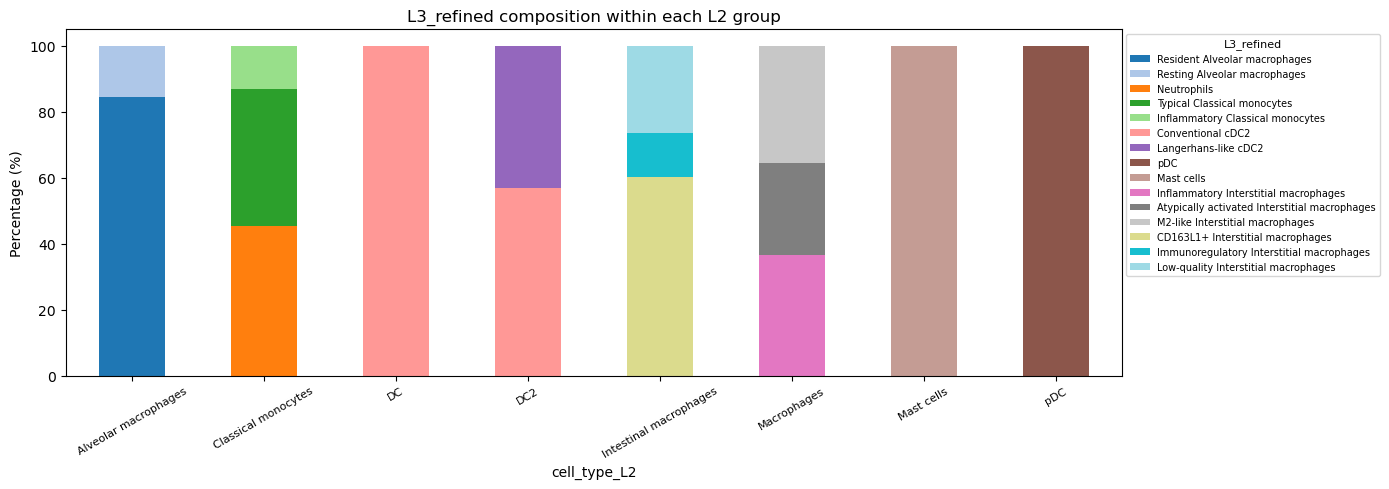

In [15]:
# ===== 8. Stacked bar: L2 composition by L3_refined =====
if 'cell_type_L2' in available and 'cell_type_L3_refined' in available:
    ct = pd.crosstab(
        adata.obs['cell_type_L2'],
        adata.obs['cell_type_L3_refined']
    )
    pct = ct.div(ct.sum(axis=1), axis=0) * 100

    # Drop columns that are all-zero across all L2 groups
    pct = pct.loc[:, pct.max(axis=0) > 1]  # keep only columns with >1% somewhere

    fig, ax = plt.subplots(figsize=(14, 5))
    pct.plot(kind='bar', stacked=True, ax=ax,
             colormap='tab20', edgecolor='none', linewidth=0)
    ax.set_title('L3_refined composition within each L2 group', fontsize=12)
    ax.set_xlabel('cell_type_L2', fontsize=10)
    ax.set_ylabel('Percentage (%)', fontsize=10)
    ax.tick_params(axis='x', labelrotation=30, labelsize=8)
    ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0),
              fontsize=7, title='L3_refined', title_fontsize=8)
    plt.tight_layout()
    plt.show()

In [16]:
# ===== 9. nan audit for L3_refined =====
# non-classical monocytes have 2029 NaN in L3_refined -- show where they fall in L2
if 'cell_type_L3_refined' in available and 'cell_type_L2' in available:
    nan_mask = adata.obs['cell_type_L3_refined'].isna()
    n_nan = nan_mask.sum()
    print(f"NaN in cell_type_L3_refined: {n_nan} cells")
    if n_nan > 0:
        print("\nL2 breakdown of NaN cells:")
        print(adata.obs.loc[nan_mask, 'cell_type_L2'].value_counts(dropna=False))
        print("\nscANVI prediction breakdown of NaN cells:")
        if 'scanvi_predictions' in adata.obs.columns:
            print(adata.obs.loc[nan_mask, 'scanvi_predictions'].value_counts(dropna=False))

NaN in cell_type_L3_refined: 2029 cells

L2 breakdown of NaN cells:
cell_type_L2
Non-classical monocytes    2029
Alveolar macrophages          0
Classical monocytes           0
DC2                           0
DC                            0
Intestinal macrophages        0
Macrophages                   0
Mast cells                    0
pDC                           0
Name: count, dtype: int64

scANVI prediction breakdown of NaN cells:
scanvi_predictions
Non-classical monocytes_c0                       1122
Non-classical monocytes_c1                        887
Inflammatory Interstitial macrophages               7
Inflammatory Classical monocytes                    6
Typical Classical monocytes                         2
Resident Alveolar macrophages                       2
M2-like Interstitial macrophages                    2
Atypically activated Interstitial macrophages       1
Langerhans-like cDC2                                0
CD163L1+ Interstitial macrophages                   0
Con